<a href="https://colab.research.google.com/github/Eyezesco/bat-pollinator-migration-analysis/blob/main/GEOSBatPollinators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesser Long-Nosed Bat: Migration & Sighting Patterns (GBIF Data)

**Question:** Where and when are lesser long-nosed bats (Leptonycteris yerbabuenae)
being observed, and what does this reveal about their migratory route?

**Data source:** GBIF Occurrence API, 295 cleaned records (2017–2026)

## Key Findings
- **Geospatial:** Sightings trace a clear north-south migratory pathway from Arizona through
  western Mexico into Guatemala/Nicaragua — consistent with the known "nectar corridor"
  this species follows along blooming agave and cactus.
- **Seasonal timing:** Two sighting peaks — April and August/September — likely reflecting
  northward spring migration and late-summer maternity colony activity.
- **Yearly trend:** General increase in sightings from 2017–2025, though this likely
  reflects growing citizen-science app usage more than a true population trend.
  2026 appears low only because the year isn't complete yet.
- **Geographic split:** Mexico (153) and the US (138) account for nearly all sightings;
  within the US, Arizona alone accounts for 136 of 138 records.

## Agtech/Conservation relevance
This species is a primary pollinator of agave, directly linking its migratory health
to the tequila/mezcal agriculture industry. Tracking  activity like this
supports both conservation efforts and crop pollination monitoring.

## Caveats
- GBIF is citizen-science/observational data — sighting counts reflect reporting
  effort, not necessarily true population size.
- Sample limited to 300 API-pulled records (5 dropped for missing coordinates).

In [16]:
import requests

response = requests.get(
    "https://api.gbif.org/v1/occurrence/search",
    params={"scientificName": "Leptonycteris yerbabuenae"}
)

data = response.json()
print(data["count"])

5969


In [ ]:
import pandas as pd

response = requests.get(
    "https://api.gbif.org/v1/occurrence/search",
    params={
        "scientificName": "Leptonycteris yerbabuenae",
        "limit": 300  # grab 300 records for now, keeps it manageable
    }
)

data = response.json()
records = data["results"]  # this is the list of actual sighting records

df = pd.DataFrame(records)
df.shape

(300, 146)

In [ ]:
df.columns.tolist()

['key',
 'datasetKey',
 'publishingOrgKey',
 'datasetCategory',
 'installationKey',
 'hostingOrganizationKey',
 'publishingCountry',
 'protocol',
 'lastCrawled',
 'lastParsed',
 'crawlId',
 'extensions',
 'basisOfRecord',
 'occurrenceStatus',
 'classifications',
 'taxonKey',
 'kingdomKey',
 'phylumKey',
 'classKey',
 'orderKey',
 'familyKey',
 'genusKey',
 'speciesKey',
 'acceptedTaxonKey',
 'scientificName',
 'scientificNameAuthorship',
 'acceptedScientificName',
 'kingdom',
 'phylum',
 'order',
 'family',
 'genus',
 'species',
 'genericName',
 'specificEpithet',
 'taxonRank',
 'taxonomicStatus',
 'iucnRedListCategory',
 'dateIdentified',
 'decimalLatitude',
 'decimalLongitude',
 'coordinateUncertaintyInMeters',
 'continent',
 'stateProvince',
 'gadm',
 'year',
 'month',
 'day',
 'eventDate',
 'startDayOfYear',
 'endDayOfYear',
 'issues',
 'modified',
 'lastInterpreted',
 'references',
 'license',
 'isSequenced',
 'identifiers',
 'media',
 'facts',
 'relations',
 'isInCluster',
 'data

In [ ]:
columns_to_keep = [
    'decimalLatitude', 'decimalLongitude',
    'country', 'stateProvince',
    'year', 'month', 'eventDate',
    'individualCount', 'basisOfRecord', 'locality'
]

df_clean = df[columns_to_keep]
df_clean.head()

,decimalLatitude,decimalLongitude,country,stateProvince,year,month,eventDate,individualCount,basisOfRecord,locality
0,24.444197,-111.572125,Mexico,Baja California Sur,2026,2,2026-02-13T09:08,NaN,HUMAN_OBSERVATION,NaN
1,24.939111,-107.353039,Mexico,Sinaloa,2026,3,2026-03-12T22:16,NaN,HUMAN_OBSERVATION,NaN
2,24.993793,-107.326017,Mexico,Sinaloa,2026,3,2026-03-12T22:15,NaN,HUMAN_OBSERVATION,NaN
3,24.856737,-107.268878,Mexico,Sinaloa,2026,3,2026-03-12T22:17,NaN,HUMAN_OBSERVATION,NaN
4,18.797280,-110.938415,Mexico,Colima,2026,3,2026-03-15T15:59,NaN,HUMAN_OBSERVATION,NaN


In [ ]:
df_clean.isnull().sum()

,0
decimalLatitude,5
decimalLongitude,5
country,5
stateProvince,6
year,0
month,0
eventDate,0
individualCount,275
basisOfRecord,0
locality,244


In [ ]:
df_clean = df_clean.dropna(subset=['decimalLatitude', 'decimalLongitude'])
df_clean.shape

(295, 10)

In [ ]:
import folium

# Center the map roughly on the average location
map_center = [df_clean['decimalLatitude'].mean(), df_clean['decimalLongitude'].mean()]
bat_map = folium.Map(location=map_center, zoom_start=5)

for idx, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=3,
        color='purple',
        fill=True,
        fill_opacity=0.6
    ).add_to(bat_map)

bat_map

In [ ]:
monthly_counts = df_clean['month'].value_counts().sort_index()
monthly_counts

,count
month,
1,11
2,4
3,18
4,45
5,9
6,17
7,15
8,64
9,68


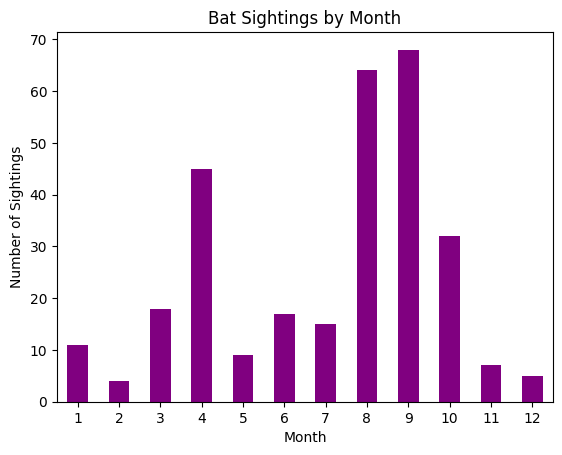

In [ ]:
import matplotlib.pyplot as plt

monthly_counts.plot(kind='bar', color='purple')
plt.title('Bat Sightings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=0)
plt.show()

In [11]:
yearly_counts = df_clean['year'].value_counts().sort_index()
yearly_counts

,count
year,
2017,14
2018,9
2019,30
2020,34
2021,49
2022,13
2023,34
2024,46
2025,41


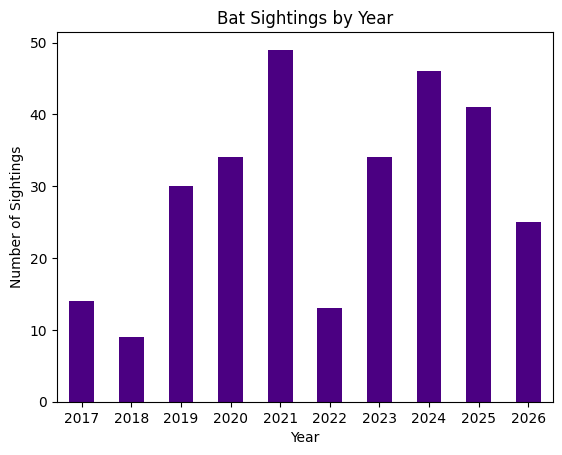

In [12]:
yearly_counts.plot(kind='bar', color='indigo')
plt.title('Bat Sightings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=0)
plt.show()

In [13]:
country_counts = df_clean['country'].value_counts()
country_counts

,count
country,
Mexico,153
United States of America,138
Guatemala,3
Nicaragua,1


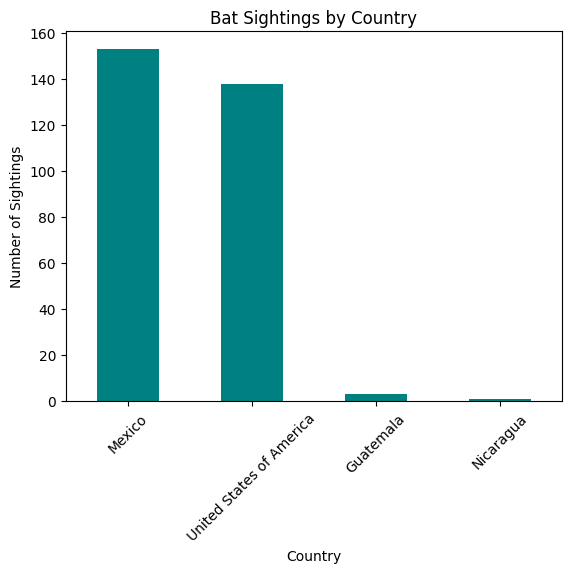

In [14]:
country_counts.plot(kind='bar', color='teal')
plt.title('Bat Sightings by Country')
plt.xlabel('Country')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45)
plt.show()

In [15]:
state_counts = df_clean[df_clean['country'] == 'United States of America']['stateProvince'].value_counts()
state_counts

,count
stateProvince,
Arizona,136
New Mexico,2
